In [1]:
import pandas as pd
import numpy as np
from typing import List, Dict, Any

from src.build_network import ResIN
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("retina")
from adjustText import adjust_text

import yaml
with open("../../src/configs.yml", "r") as configs:
    configs = yaml.safe_load(configs)

ROOTPATH = configs["ROOTPATH"]
ROOTPATH2 = configs["ROOTPATH2"]
# OUTPATH = "../../output/results-summary-082824/"
# OUTPATH = "../../output/results-summary-092724/"

print(configs)

{'ROOTPATH': '/Users/yijingch/Documents/GITHUB/broken-egg-polarization/', 'GITHUBPATH': '/Users/yijingch/Documents/GITHUB/', 'ROOTPATH2': '/Users/yijingch/Dropbox/CSS 2023 Attitude Networks/ANES/Cumulative'}


In [2]:
anes_all = pd.read_csv(ROOTPATH + "data/anes_out_090624.csv").drop(columns=["Unnamed: 0"])
YEARS = [2000, 2004, 2008, 2012, 2016, 2020]
anes_all = anes_all[anes_all["year"].isin(YEARS)]
anes_all["ft_rep_net"] = anes_all["ft_rep"] - anes_all["ft_dem"] # compute the net value of ft rep/dem
PARTISAN_LABEL_CATG = {
    1: -1, 2: -1, 3: -1, 
    4: 0,
    5: 1, 6: 1, 7: 1,
}

anes_all["dem_rep_3"] = anes_all["dem_rep"].map(lambda x: PARTISAN_LABEL_CATG[x] if not np.isnan(x) else np.NaN)
anes_all = anes_all[anes_all["dem_rep_3"].notna()]
print("# of NaN:", len(anes_all[anes_all["dem_rep_3"].isna()]))
print("# of independents:", len(anes_all[anes_all["dem_rep_3"]==0]))
anes_all.head()


# of NaN: 0
# of independents: 2948


,year,gov_health,guar_jobs,us_isolate,aid_black,abort,spend_serv,def_spend,aff_act_1,aff_act_2,...,hw_his,hw_asian,it_access,it_campaign,left_right,lbrl_cnsv,dem_rep,weights,ft_rep_net,dem_rep_3
11295,2000,5.0,6.0,NaN,NaN,2.0,3.0,6.0,5.0,5.0,...,4.0,4.0,1.0,1.0,NaN,NaN,5.0,1.2886,16.0,1.0
11296,2000,NaN,NaN,2.0,NaN,4.0,NaN,NaN,5.0,5.0,...,7.0,1.0,1.0,5.0,NaN,NaN,3.0,0.8959,NaN,-1.0
11297,2000,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,7.0,...,6.0,5.0,1.0,5.0,NaN,NaN,1.0,1.0454,-30.0,-1.0
11298,2000,NaN,NaN,2.0,NaN,4.0,NaN,NaN,5.0,5.0,...,4.0,1.0,5.0,5.0,NaN,5.0,3.0,0.6005,-5.0,-1.0
11299,2000,NaN,NaN,NaN,NaN,3.0,NaN,NaN,5.0,5.0,...,5.0,1.0,5.0,5.0,NaN,6.0,7.0,1.9270,70.0,1.0


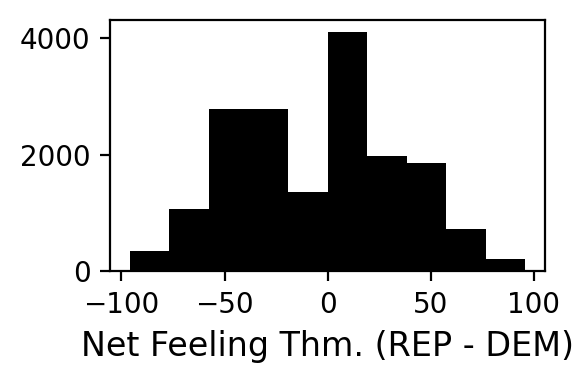

In [3]:
fig,ax = plt.subplots(figsize=(3,2))
plt.hist(anes_all["ft_rep_net"], color="black", bins=10)
plt.xlabel("Net Feeling Thm. (REP - DEM)", fontsize=12)
plt.tight_layout()

In [31]:
NODE_COLS = [
     "spend_serv", "gov_health", "guar_jobs", "abort", "aid_black", "spend_school", "spend_crime", "spend_welfare",
    # "spend_serv", "gov_health", "guar_jobs", "abort", "aid_black", # the final selection
    # "immigrat", "gun_own", "spend_school", "spend_crime", "spend_welfare",
    # "spend_poor", "penalty_favopp", "gay_discr", "aff_act_2", 
    # "left_right", "lbrl_cnsv"
]

# COV_COLS = ["ft_rep_net"]
COV_COLS = ["dem_rep_3"]

In [32]:
RESIN_DICT = {}
NEUTRAL_VAL_DICT = {}
for year in YEARS:
    print("processing:", year)
    anes_year = anes_all[anes_all["year"]==year].copy()
    anes_year = anes_year[NODE_COLS + COV_COLS]
    resin = ResIN(df=anes_year, node_cols=NODE_COLS)
    resin.make_graph(square_corr=False, remove_nan=True)
    resin.compute_covariates(covariate_cols=COV_COLS)
    resin.adjust_coordinates()
    resin.get_item_size()
    resin.set_edge_distance()
    RESIN_DICT[year] = resin
    # NEUTRAL_VAL_DICT[year] = np.nanmean(anes_year["ft_rep_net"])

processing: 2000
processing: 2004
processing: 2008
processing: 2012
processing: 2016
processing: 2020


In [33]:
YEARS_TO_FLIP = [2004, 2020]
for y in YEARS_TO_FLIP:
    RESIN_DICT[y].left_right_flip()

In [34]:
def distinguish_operational_symbolic(
        label:str, 
        symbolic_vars=["left_right", "lbrl_cnsv"],
        color=True,
        cmap={0:"#658147", 1:"#E76F51"}) -> int:
    out = 0
    for var in symbolic_vars:
        if var in label:
            out = 1
            break 
    if color:
        return cmap[out]
    else:
        return out

Text(0.5, 1.08, 'ResIN snapshots for ANES (2000-2020)')

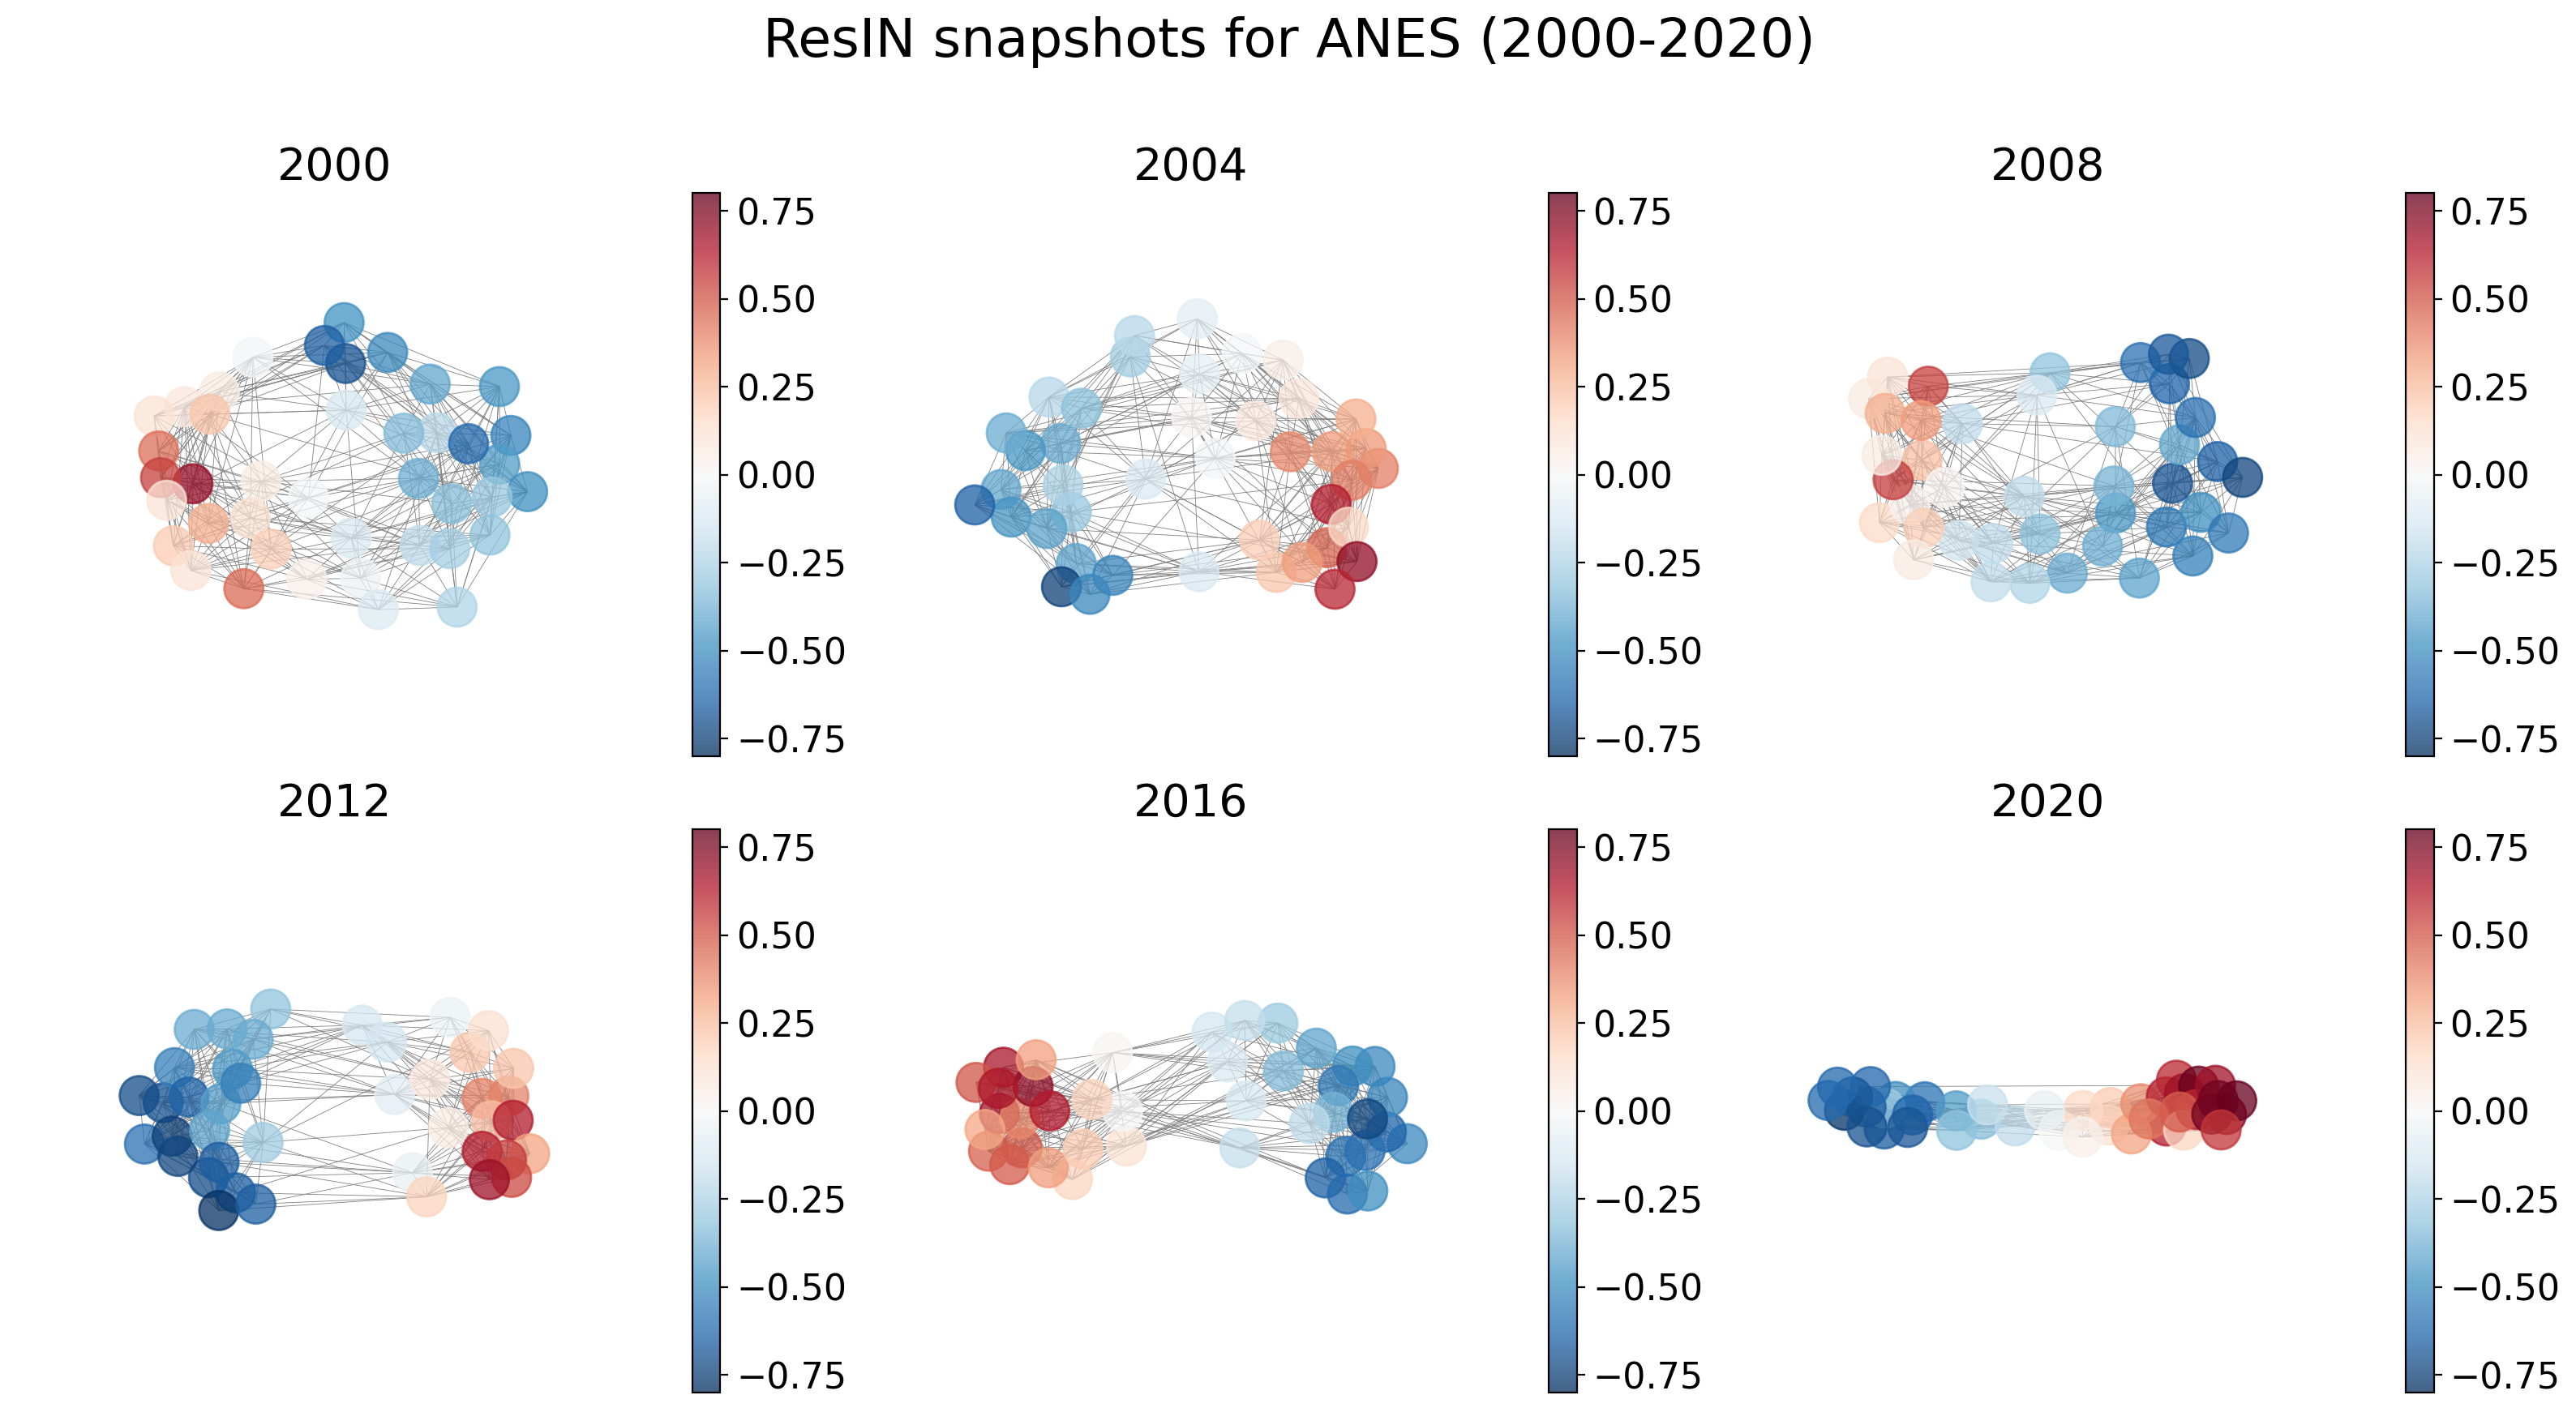

In [35]:
from sklearn.preprocessing import MinMaxScaler

color_var = COV_COLS[0]
fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(16,8))
ax = [x for ls in ax for x in ls]

for i, (year,resin) in enumerate(RESIN_DICT.items()):
    NEUTRAL_VAL = 0
    # colors = [distinguish_operational_symbolic(x) for x in list(resin.g.nodes())]
    colors = [resin.node_attrs[color_var][x] for x in resin.g.nodes()]
    color_bound = max([NEUTRAL_VAL-min(colors), max(colors)-NEUTRAL_VAL])
    sizes = np.array([resin.node_attrs["size"][x] for x in resin.g.nodes()]).reshape(-1,1)
    scaler = MinMaxScaler().fit(sizes)
    sizes = scaler.transform(sizes).reshape(-1)
    sizes = sizes*2000**1/2

    nodes_plot = nx.draw_networkx_nodes(
        resin.g, ax=ax[i], 
        pos=resin.pos_new, 
        # node_size=sizes,
        node_color=colors, 
        # node_color="lightgrey",
        cmap="RdBu_r", 
        alpha=.75, label=False,
        # vmin=NEUTRAL_VAL-color_bound, vmax=NEUTRAL_VAL+color_bound,  # if not normalizing colorbar
        vmin=-.8, vmax=.8
        ) 
    edges_plot = nx.draw_networkx_edges(
        resin.g, ax=ax[i], edge_color="grey", pos=resin.pos_new, width=.3,
    )
    # nx.draw_networkx_labels(resin.g, ax=ax[i], pos=resin.pos_new)
    ax[i].set_title(year, fontsize=20)
    clb = plt.colorbar(nodes_plot)
    clb.ax.tick_params(labelsize=16)
    ax[i].set_ylim(-1.65, 1.65)
    ax[i].set_xlim(-1.65, 1.65)
    ax[i].axis("off")
plt.tight_layout()
plt.suptitle(f"ResIN snapshots for ANES (2000-2020)", fontsize=24, y=1.08)
# plt.savefig(OUTPATH + f"anes_resin_snapshot_2000_2020_FTNET_COLOR_with_lab.pdf", dpi=300, bbox_inches="tight")

In [25]:
# set edge attribute: 1_weight for closeness calculation
def set_edge_distance(g):
    ds = {}
    for e in g.edges(data=True):
        w = e[2]["weight"]
        ds[(e[0],e[1])] = 1-w
    nx.set_edge_attributes(g, ds, "distance")

def get_centrality_df(g):
    df = pd.DataFrame()
    df["node"] = list(g.nodes())
    df["strength"] = [x[1] for x in nx.degree(g, weight="weight")]
    df["betweenness"] = dict(nx.betweenness_centrality(g, weight="distance")).values()
    df["closeness"] = dict(nx.closeness_centrality(g, distance="distance")).values()
    return df

cent_df_all = pd.DataFrame()
for year,resin in RESIN_DICT.items():
    g = resin.g
    set_edge_distance(g)
    cent_df = get_centrality_df(g)
    cent_df = cent_df.melt(id_vars="node", value_vars=["strength", "betweenness", "closeness"])
    cent_df["year"] = year 
    cent_df["node_type"] = cent_df["node"].map(lambda x: distinguish_operational_symbolic(x, color=False))
    cent_df_all = pd.concat([cent_df, cent_df_all])

cent_df_all


,node,variable,value,year,node_type
0,aid_black:3.0,strength,0.996528,2020,0
1,guar_jobs:4.0,strength,1.021524,2020,0
2,abort:3.0,strength,0.707044,2020,0
3,guar_jobs:5.0,strength,1.058414,2020,0
4,gov_health:4.0,strength,0.866098,2020,0
...,...,...,...,...,...
109,aid_black:2.0,closeness,0.643206,2000,0
110,aid_black:5.0,closeness,0.647712,2000,0
111,gov_health:5.0,closeness,0.656294,2000,0
112,gov_health:2.0,closeness,0.663865,2000,0


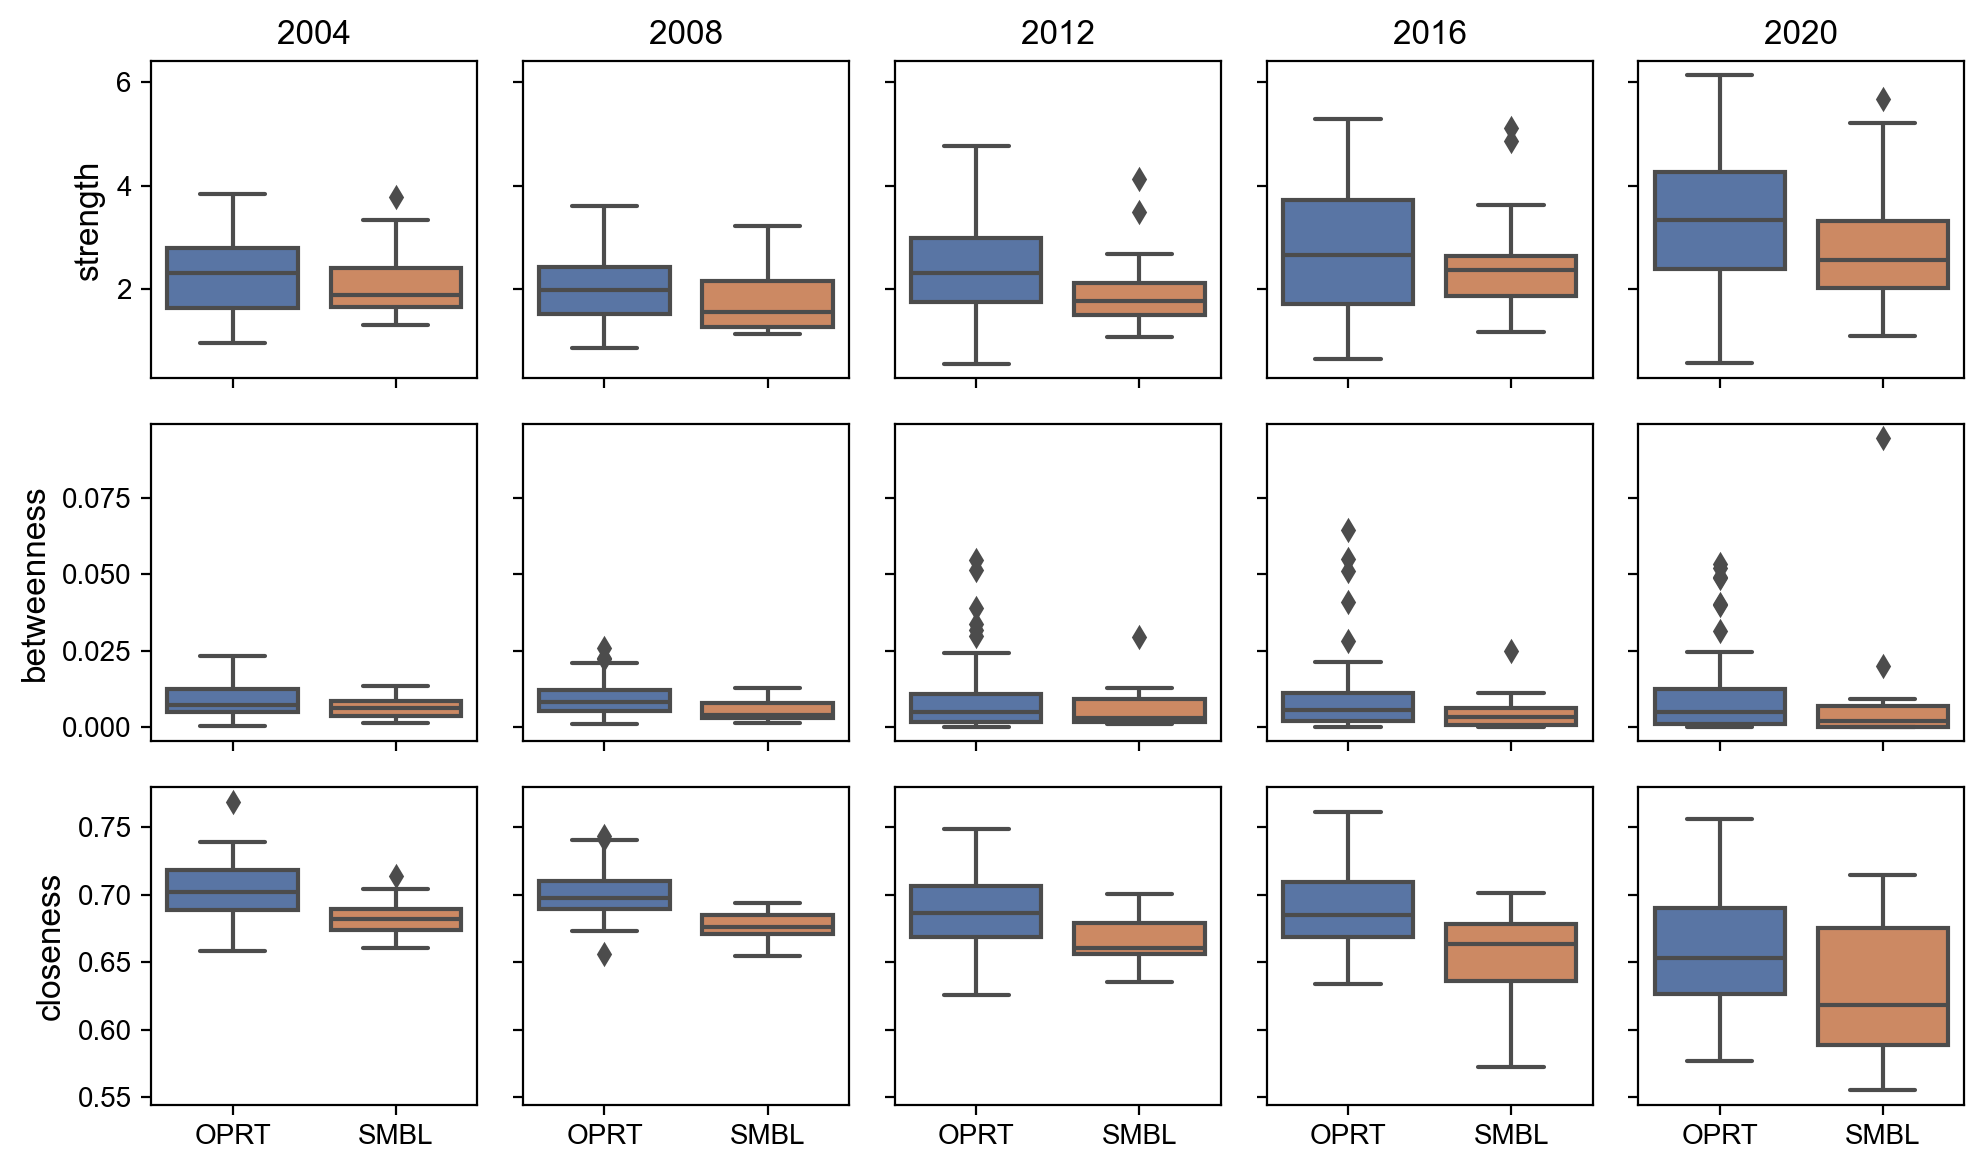

In [ ]:
YEARS = [2004, 2008, 2012, 2016, 2020]
VARS = ["strength", "betweenness", "closeness"]

import seaborn as sns
fig,axes = plt.subplots(figsize=(10,6), nrows=len(VARS), ncols=len(YEARS), sharex=True, sharey="row")
sns.set(style="whitegrid")
for i,var in enumerate(VARS):
    for j,year in enumerate(YEARS):
        subdf = cent_df_all[(cent_df_all["year"]==year)&(cent_df_all["variable"]==var)]
        sns.boxplot(x="node_type", y="value", data = subdf, ax=axes[i,j])
        axes[i,j].set_xlabel("")
        axes[i,j].set_ylabel("")
        if i==0:
            axes[i,j].set_title(year, fontsize=12)
        if i==2:
            axes[i,j].set_xticks([0,1], ["OPRT", "SMBL"])
    axes[i,0].set_ylabel(var, fontsize=12)
plt.tight_layout()
